In [946]:
import pandas as pd
import numpy as np
import xgboost as xgb
import time
from sklearn.metrics import mean_squared_error
import shap
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

### Load Data

In [947]:
df = pd.read_csv('../data/features_30min.csv', parse_dates=['DATE_TIME'])

In [948]:
df.head()

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,minute,hour,...,temp_rolling_mean_192,temp_rolling_std_192,solar_elevation,solar_azimuth,clear_sky_ghi,clear_sky_index,clear_sky_index_lag_96,clear_sky_index_lag_144,clear_sky_index_lag_192,clear_sky_index_lag_mean
0,2020-05-19 02:00:00,0.0,0.0,0.0,6.878367e+06,22.786668,20.760914,0.0,0,2,...,26.670279,3.974028,0.0,39.543339,0.0,0.0,0.0,0.0,0.0,0.0
1,2020-05-19 02:30:00,0.0,0.0,0.0,6.878367e+06,22.903825,20.830347,0.0,30,2,...,26.637502,3.968138,0.0,46.738154,0.0,0.0,0.0,0.0,0.0,0.0
2,2020-05-19 03:00:00,0.0,0.0,0.0,6.878367e+06,22.977873,20.816942,0.0,0,3,...,26.604765,3.962591,0.0,52.452925,0.0,0.0,0.0,0.0,0.0,0.0
3,2020-05-19 03:30:00,0.0,0.0,0.0,6.878367e+06,23.058529,20.810249,0.0,30,3,...,26.569593,3.959588,0.0,57.016095,0.0,0.0,0.0,0.0,0.0,0.0
4,2020-05-19 04:00:00,0.0,0.0,0.0,6.878367e+06,23.137478,20.812078,0.0,0,4,...,26.534102,3.957252,0.0,60.695337,0.0,0.0,0.0,0.0,0.0,0.0


In [949]:
TARGET = 'AC_POWER'
feature_cols = [
    'hour', 'month', 'dayofweek', 'hour_sin', 'hour_cos', 'hour_squared', 'part_of_day', 'is_daytime',
    'prev_day_peak', 'hour_avg',
    'ac_rolling_mean_48', 'ac_rolling_mean_96', 'ac_rolling_mean_192',
    'ac_rolling_std_48', 'ac_rolling_std_96', 'ac_rolling_std_192', 
    'irr_rolling_mean_48', 'irr_rolling_mean_96', 'irr_rolling_mean_192',
    'temp_rolling_mean_192', 'temp_rolling_std_192',
    'irr_rolling_std_48', 'irr_rolling_std_96', 'irr_rolling_std_192', 
    'ac_rolling_max_192', 'ac_rolling_min_192', 'ac_rolling_range_192',
    'solar_elevation', 'solar_azimuth',
    'clear_sky_ghi', 
    'ac_lag_mean', 'irr_lag_mean', 'temp_lag_mean', 'ac_lag_trend', 
    'clear_sky_index_lag_mean', 'efficiency_lag_mean', 'daily_yield_lag_mean', 'module_temp_lag_mean', 'dc_lag_mean', 
    'module_temp_rolling_mean_192', 'module_temp_rolling_std_192'
]

# Temporal splits: ~24 days train, ~5 days test, ~5 days eval
train_end = '2020-06-08'
test_end = '2020-06-13'

train = df[df['DATE_TIME'] < train_end]
test = df[(df['DATE_TIME'] >= train_end) & (df['DATE_TIME'] < test_end)]
eval_set = df[df['DATE_TIME'] >= test_end]

X_train, y_train = train[feature_cols], train[TARGET]
X_test, y_test = test[feature_cols], test[TARGET]
X_eval, y_eval = eval_set[feature_cols], eval_set[TARGET]

print(f'Train: {len(train)} rows ({train["DATE_TIME"].min().date()} → {train["DATE_TIME"].max().date()})')
print(f'Test:  {len(test)} rows ({test["DATE_TIME"].min().date()} → {test["DATE_TIME"].max().date()})')
print(f'Eval:  {len(eval_set)} rows ({eval_set["DATE_TIME"].min().date()} → {eval_set["DATE_TIME"].max().date()})')

Train: 900 rows (2020-05-19 → 2020-06-07)
Test:  230 rows (2020-06-08 → 2020-06-12)
Eval:  230 rows (2020-06-13 → 2020-06-17)


### Default XGBoost

We start with XGBoost (Extreme Gradient Boosting) as our first model. XGBoost builds decision trees sequentially, where each new tree corrects the errors of the previous ones. It is well-suited for tabular data with engineered features and handles non-linear relationships naturally through tree splits. It is robust to correlated and redundant features - important given the high correlations between solar variables (irradiation, temperature, power output). It includes built-in regularisation parameters (max_depth, reg_alpha, min_child_weight) that are critical for preventing overfitting on a small dataset of only 34 days. Finally, XGBoost is fast to train and predict, making it practical for production deployment where forecasts need to be generated frequently across many sites.

The default model shows severe overfitting - train RMSE of ~0.17 compared to test RMSE of ~131. With 900 training rows and 41 features, the deep trees (max_depth=6) memorise the training data almost perfectly without learning generalisable patterns.

In [950]:
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    reg_alpha=1,
)

model.fit(X_train, y_train)

preds_test = model.predict(X_test)

preds_train = model.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train, preds_train))
print(f'Train RMSE: {rmse:.2f}')

rmse = np.sqrt(mean_squared_error(y_test, preds_test))
print(f'Test RMSE: {rmse:.2f}')

Train RMSE: 0.17
Test RMSE: 131.87


### Tuned XGBoost

The tuning was done using GridSearchCV with 3-fold TimeSeriesSplit to systematically search across regularisation parameters. The search focused on constraining model complexity to address the severe overfitting observed with default parameters.

Best parameters: max_depth=2, learning_rate=0.01, n_estimators=400, reg_alpha=6.0, min_child_weight=20, subsample=0.7, colsample_bytree=0.7. Every parameter points toward strong regularisation - very shallow trees, slow learning rate, high L1 penalty, and large minimum leaf size. This is consistent with having limited training data where the model must be prevented from fitting to noise.

The tuned model closed the overfitting gap dramatically: train/test RMSE ratio improved to 1.10, while test RMSE improved from the default baseline. 

In [951]:
param_grid = {
    'max_depth': [2, 3],
    'learning_rate': [0.005, 0.01, 0.05],
    'n_estimators': [400, 500],
    'subsample': [0.5, 0.7],
    'reg_alpha': [6.0, 8.0, 10.0],
    'min_child_weight': [15, 20, 25],
    'colsample_bytree': [0.7, 0.8],
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=1,
)

grid_search.fit(X_train, y_train)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV RMSE: {-grid_search.best_score_:.2f}')

best_model = grid_search.best_estimator_
preds_test_tuned = best_model.predict(X_test)

preds_train_tuned = best_model.predict(X_train)

print(f'\nTrain RMSE:  {np.sqrt(mean_squared_error(y_train, preds_train_tuned)):.2f}')
print(f'\nTest RMSE:  {np.sqrt(mean_squared_error(y_test, preds_test_tuned)):.2f}')

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 20, 'n_estimators': 400, 'reg_alpha': 6.0, 'subsample': 0.7}
Best CV RMSE: 127.90

Train RMSE:  103.51

Test RMSE:  114.86


#### SHAP Feature Analysis

SHAP (SHapley Additive exPlanations) was used to understand which features drive individual predictions, rather than relying solely on global feature importance which can be misleading with correlated features.  

SHAP analysis on the tuned model revealed that solar_elevation (SHAP ~132) and clear_sky_ghi (SHAP ~100) dominate predictions - both are physics-based features derived from sun position and atmospheric modelling. 

The next most important features are hour_cos (~45) and ac_lag_mean (~40) - capturing the daily cycle and recent production history. 

Features with near-zero SHAP values such as is_daytime, part_of_day, ac_rolling_min_192, module_temp_rolling_mean_192, ac_rolling_std_192 were pruned from the final model. SHAP-driven pruning reduced the feature set from 41 to 14 features while maintaining test RMSE, confirming that the regularised model was already ignoring these features internally. The leaner model is simpler to deploy and maintain in production.

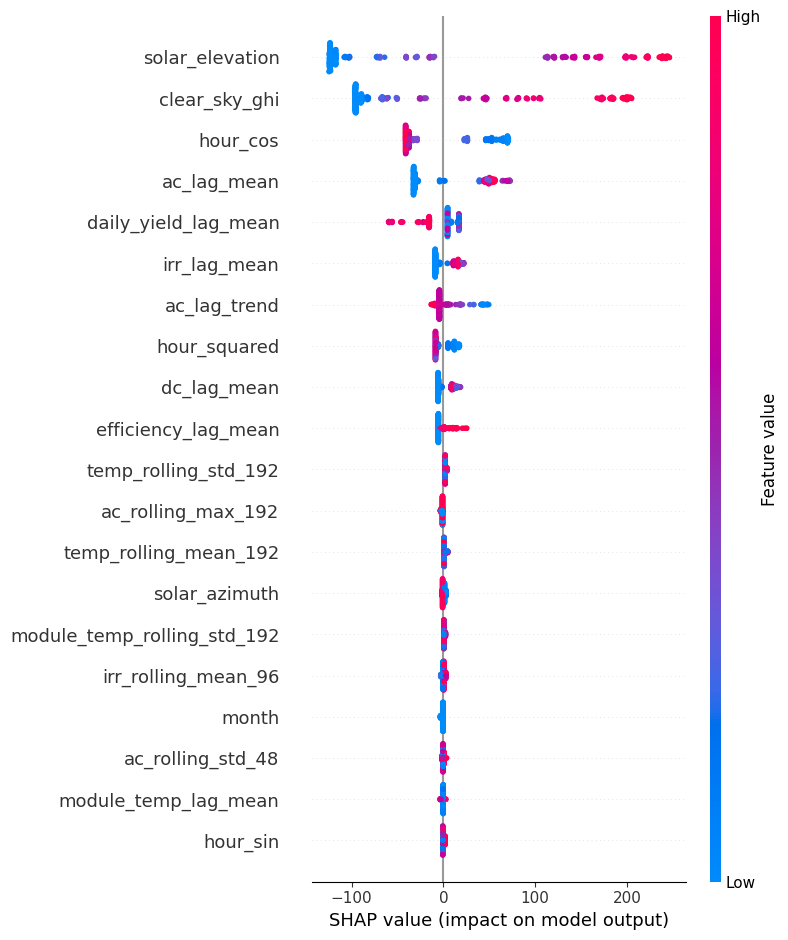

In [952]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test[feature_cols])

In [953]:
# Get mean absolute SHAP value per feature
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

print('=== SHAP Feature Importance ===')
print(shap_importance.to_string())

# Features with near-zero SHAP
threshold = shap_importance.mean() * 1.3
useless = shap_importance[shap_importance < threshold]
print(f'\nFeatures below threshold ({threshold:.4f}):')
print(useless.to_string())

=== SHAP Feature Importance ===
solar_elevation                 131.583450
clear_sky_ghi                    99.563950
hour_cos                         44.524086
ac_lag_mean                      39.761494
daily_yield_lag_mean             14.740495
irr_lag_mean                     11.538894
ac_lag_trend                      9.747983
hour_squared                      9.494758
dc_lag_mean                       8.077531
efficiency_lag_mean               5.895276
temp_rolling_std_192              2.505523
ac_rolling_max_192                1.537393
temp_rolling_mean_192             1.362690
solar_azimuth                     1.102694
module_temp_rolling_std_192       0.899020
irr_rolling_mean_96               0.897611
month                             0.763101
ac_rolling_std_48                 0.685916
module_temp_lag_mean              0.667365
hour_sin                          0.665277
ac_rolling_range_192              0.610528
ac_rolling_mean_192               0.561328
irr_rolling_mean_48   

#### Model Pruning

SHAP-driven pruning revealed that the model is doing well even with only a couple of top features provided. The pruned model achieves a test RMSE of 114.10 compared to 114.86 with all 41 features - almost the same despite using 88% fewer features. The train/test ratio improved from 1.11 to 1.04.

This confirms that solar PV forecasting at 48-hour horizon is fundamentally driven by a small number of signals: sun position, recent production history, and time-of-day encoding. The remaining 36 features add complexity without improving predictions on this dataset.

In [954]:
keep_features = shap_importance[shap_importance >= threshold].index.tolist()
drop_features = shap_importance[shap_importance < threshold].index.tolist()

print(f'Keeping {len(keep_features)} features, dropping {len(drop_features)}')

# All features
m_all = xgb.XGBRegressor(**grid_search.best_params_, random_state=42, n_jobs=-1)
m_all.fit(X_train, y_train)
train_rmse_all = np.sqrt(mean_squared_error(y_train, m_all.predict(X_train)))
test_rmse_all = np.sqrt(mean_squared_error(y_test, m_all.predict(X_test)))

# Pruned features
m_pruned = xgb.XGBRegressor(**grid_search.best_params_, random_state=42, n_jobs=-1)
m_pruned.fit(train[keep_features], y_train)
train_rmse_pruned = np.sqrt(mean_squared_error(y_train, m_pruned.predict(train[keep_features])))
test_rmse_pruned = np.sqrt(mean_squared_error(y_test, m_pruned.predict(test[keep_features])))

print(f'\n{"":20s} {"Train RMSE":>12s} {"Test RMSE":>12s} {"Ratio":>8s}')
print(f'{"All features ("+str(len(feature_cols))+")":20s} {train_rmse_all:12.2f} {test_rmse_all:12.2f} {test_rmse_all/train_rmse_all:8.2f}')
print(f'{"Pruned ("+str(len(keep_features))+")":20s} {train_rmse_pruned:12.2f} {test_rmse_pruned:12.2f} {test_rmse_pruned/train_rmse_pruned:8.2f}')

Keeping 5 features, dropping 36

                       Train RMSE    Test RMSE    Ratio
All features (41)          103.51       114.86     1.11
Pruned (5)                 109.50       114.10     1.04


In [955]:
X_train_pruned = train[keep_features]
X_test_pruned = test[keep_features]
X_eval_pruned = eval_set[keep_features]

### Default Ridge Regression

As a second model, Ridge regression provides a fundamentally different approach — a linear model with L2 regularisation. Where XGBoost learns complex non-linear relationships through tree splits, Ridge fits a single linear combination of features. This tests whether the solar forecasting relationship is largely linear or whether the non-linear patterns XGBoost captures are essential. From what was seen in the data, the relationships seem to be mostly linear.

Ridge is also orders of magnitude faster to train and predict, making it an attractive production option if accuracy is comparable.

In [956]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_eval_scaled = scaler.transform(X_eval)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

preds_ridge_test = ridge.predict(X_test_scaled).clip(0)

preds_ridge_train = ridge.predict(X_train_scaled).clip(0)
preds_ridge_eval = ridge.predict(X_eval_scaled).clip(0)

print(f'Train RMSE: {np.sqrt(mean_squared_error(y_train, preds_ridge_train)):.2f}')
print(f'Test RMSE:  {np.sqrt(mean_squared_error(y_test, preds_ridge_test)):.2f}')

for name, y_true, preds, data in [('Train', y_train, preds_ridge_train, train), 
                                    ('Test', y_test, preds_ridge_test, test)]:
    results = data[['DATE_TIME', TARGET]].copy()
    results['predicted'] = preds
    results['block'] = results['DATE_TIME'].dt.hour // 4
    
    daily = results.groupby(results['DATE_TIME'].dt.date).agg({TARGET: 'sum', 'predicted': 'sum'})
    
    print(f'\n=== {name} Set ===')
    print(f'Half-hourly RMSE: {np.sqrt(mean_squared_error(y_true, preds)):.2f}')
    print(f'Daily RMSE: {np.sqrt(mean_squared_error(daily[TARGET], daily["predicted"])):.2f}')
    
    print('4h block RMSE:')
    for b in range(6):
        hours = f'{b*4:02d}:00-{(b+1)*4:02d}:00'
        mask = results['block'] == b
        if mask.sum() > 0:
            r = np.sqrt(mean_squared_error(results.loc[mask, TARGET], results.loc[mask, 'predicted']))
            print(f'  {hours}: RMSE {r:.2f}')

Train RMSE: 105.17
Test RMSE:  133.84

=== Train Set ===
Half-hourly RMSE: 105.17
Daily RMSE: 1081.28
4h block RMSE:
  00:00-04:00: RMSE 22.02
  04:00-08:00: RMSE 44.17
  08:00-12:00: RMSE 136.68
  12:00-16:00: RMSE 186.40
  16:00-20:00: RMSE 79.27
  20:00-24:00: RMSE 15.92

=== Test Set ===
Half-hourly RMSE: 133.84
Daily RMSE: 3824.32
4h block RMSE:
  00:00-04:00: RMSE 73.79
  04:00-08:00: RMSE 91.38
  08:00-12:00: RMSE 198.45
  12:00-16:00: RMSE 193.00
  16:00-20:00: RMSE 89.52
  20:00-24:00: RMSE 76.99


### Tuned Ridge Regression

GridSearchCV with TimeSeriesSplit was used to search across alpha values. The best alpha was 150.0, achieving a train RMSE of 119.78 and test RMSE of 115.81 with a train/test ratio of 0.97. The higher alpha increased regularisation, which reduced overfitting — the default model (alpha=1.0) had a lower train RMSE but a wider gap between train and test performance. Overall performance is similar between default and tuned Ridge, confirming that the linear relationships in the data are stable and not highly sensitive to regularisation strength.

In [957]:
param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 125.0, 150.0, 300.0]}

tscv = TimeSeriesSplit(n_splits=3)

ridge_search = GridSearchCV(
    Ridge(),
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

ridge_search.fit(X_train_scaled, y_train)

best_ridge = ridge_search.best_estimator_
preds_train = best_ridge.predict(X_train_scaled).clip(0)
preds_test = best_ridge.predict(X_test_scaled).clip(0)
preds_eval = best_ridge.predict(X_eval_scaled).clip(0)

print(f'Best alpha: {ridge_search.best_params_["alpha"]}')
print(f'Train RMSE: {np.sqrt(mean_squared_error(y_train, preds_train)):.2f}')
print(f'Test RMSE:  {np.sqrt(mean_squared_error(y_test, preds_test)):.2f}')
print(f'Ratio:      {np.sqrt(mean_squared_error(y_test, preds_test)) / np.sqrt(mean_squared_error(y_train, preds_train)):.2f}')

Best alpha: 150.0
Train RMSE: 119.78
Test RMSE:  115.81
Ratio:      0.97


### Error Metrics

Both models achieve similar half-hourly RMSE on the test set (XGBoost 114.10, Ridge 115.81), but XGBoost generalises better on the eval set (134.51 vs 147.46).

The 4-hour block breakdown reveals where the models differ. During peak solar hours (08:00-16:00), both models struggle with cloud-driven variability — Ridge actually slightly outperforms XGBoost on the test set for the 12:00-16:00 block (160 vs 175) but the advantage disappears on eval (268 vs 253).

The key difference is nighttime performance. XGBoost achieves near-perfect night predictions (RMSE 7-14 kW) because tree splits learn the hard cutoff at sunset — if solar elevation is zero, predict zero. Ridge cannot learn this discontinuity and instead predicts small non-zero values at night, resulting in nighttime RMSE of 15-41 kW. This is a fundamental limitation of linear models for solar forecasting.

Daily RMSE is notably worse for Ridge on eval (3,300 vs 1,963 kW), as the nighttime errors and transition period inaccuracies accumulate across 48 half-hourly predictions per day.

In [958]:
def evaluate_model(model, X_sets, y_sets, data_sets, set_names, feature_cols=None):
    for name, X, y_true, data in zip(set_names, X_sets, y_sets, data_sets):
        if feature_cols:
            preds = model.predict(data[feature_cols]).clip(0)
        else:
            preds = model.predict(X).clip(0)
        
        results = data[['DATE_TIME', TARGET]].copy()
        results['predicted'] = preds
        results['block'] = results['DATE_TIME'].dt.hour // 4
        
        daily = results.groupby(results['DATE_TIME'].dt.date).agg({TARGET: 'sum', 'predicted': 'sum'})
        
        print(f'\n=== {name} Set ===')
        print(f'Half-hourly RMSE: {np.sqrt(mean_squared_error(y_true, preds)):.2f}')
        print(f'Daily RMSE: {np.sqrt(mean_squared_error(daily[TARGET], daily["predicted"])):.2f}')
        
        print('4h block RMSE:')
        for b in range(6):
            hours = f'{b*4:02d}:00-{(b+1)*4:02d}:00'
            mask = results['block'] == b
            if mask.sum() > 0:
                r = np.sqrt(mean_squared_error(results.loc[mask, TARGET], results.loc[mask, 'predicted']))
                print(f'  {hours}: RMSE {r:.2f}')

# XGBoost
print('========== XGBoost ==========')
evaluate_model(m_pruned, 
               [X_train_pruned, X_test_pruned, X_eval_pruned], 
               [y_train, y_test, y_eval], 
               [train, test, eval_set], 
               ['Train', 'Test', 'Eval'])

# Ridge
print('\n========== Ridge ==========')
evaluate_model(best_ridge, 
               [X_train_scaled, X_test_scaled, X_eval_scaled], 
               [y_train, y_test, y_eval], 
               [train, test, eval_set], 
               ['Train', 'Test', 'Eval'])

========== XGBoost ==========

=== Train Set ===
Half-hourly RMSE: 109.50
Daily RMSE: 1583.12
4h block RMSE:
  00:00-04:00: RMSE 12.90
  04:00-08:00: RMSE 36.59
  08:00-12:00: RMSE 151.24
  12:00-16:00: RMSE 190.50
  16:00-20:00: RMSE 82.19
  20:00-24:00: RMSE 9.25

=== Test Set ===
Half-hourly RMSE: 114.10
Daily RMSE: 2351.91
4h block RMSE:
  00:00-04:00: RMSE 13.59
  04:00-08:00: RMSE 42.34
  08:00-12:00: RMSE 193.83
  12:00-16:00: RMSE 174.92
  16:00-20:00: RMSE 68.47
  20:00-24:00: RMSE 8.28

=== Eval Set ===
Half-hourly RMSE: 134.51
Daily RMSE: 1962.58
4h block RMSE:
  00:00-04:00: RMSE 13.59
  04:00-08:00: RMSE 49.88
  08:00-12:00: RMSE 165.54
  12:00-16:00: RMSE 253.40
  16:00-20:00: RMSE 98.72
  20:00-24:00: RMSE 7.34

========== Ridge ==========

=== Train Set ===
Half-hourly RMSE: 119.78
Daily RMSE: 1506.35
4h block RMSE:
  00:00-04:00: RMSE 15.38
  04:00-08:00: RMSE 50.86
  08:00-12:00: RMSE 152.66
  12:00-16:00: RMSE 213.05
  16:00-20:00: RMSE 95.86
  20:00-24:00: RMSE 9.27

### Compute Metrics

Device: MacBook M4 Pro 2024, 24GB RAM

In [960]:
def compute_time(name, model, X_train_data, X_test_data, y_train):
    start = time.time()
    model.fit(X_train_data, y_train)
    train_time = time.time() - start
    
    start = time.time()
    _ = model.predict(X_test_data)
    inference_time = time.time() - start
    
    print(f'{name:45s} Training: {train_time:.4f}s  Inference: {inference_time:.6f}s')

compute_time('XGBoost Default (41 features)',
    xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1, 
                      subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=1), # Single thread is faster for small datasets
    X_train, X_test, y_train)

compute_time('XGBoost Tuned + Pruned (5 features)',
    xgb.XGBRegressor(**{**grid_search.best_params_, 'n_jobs': 1}, random_state=42),
    X_train_pruned, X_test_pruned, y_train)

compute_time('Ridge Default (41 features)',
    Ridge(alpha=1.0),
    X_train_scaled, X_test_scaled, y_train)

compute_time('Ridge Tuned (41 features)',
    Ridge(alpha=ridge_search.best_params_['alpha']),
    X_train_scaled, X_test_scaled, y_train)

XGBoost Default (41 features)                 Training: 0.4849s  Inference: 0.003178s
XGBoost Tuned + Pruned (5 features)           Training: 0.0198s  Inference: 0.000698s
Ridge Default (41 features)                   Training: 0.0020s  Inference: 0.000061s
Ridge Tuned (41 features)                     Training: 0.0003s  Inference: 0.000036s


### Production Recommendations

XGBoost is the recommended model for production deployment. 

Both models achieve similar test RMSE (~114-116 kW), but XGBoost generalises better on the eval set (134.51 vs 147.46 kW). XGBoost picks up non-linear patterns that Ridge cannot — things like the hard cutoff at sunset where output drops to zero, and how solar elevation interacts with recent weather conditions. These patterns would likely become more useful with a longer training history. XGBoost is also easier to interpret through SHAP, which helps with debugging and understanding what the model is actually doing.

That said, Ridge is surprisingly competitive given how simple it is. The fact that a linear model nearly matches XGBoost suggests that the core solar forecasting relationship is mostly linear - sun position and recent production history explain most of the variance. Ridge could work well as a fast fallback model since it trains almost instantly.

The biggest limitation of both models is the lack of weather forecast data. Right now the model has no way of knowing whether tomorrow will be sunny or cloudy - it can only look at what happened 2-4 days ago and hope the pattern continues. Integrating a weather forecast API like Solcast or ECMWF for predicted cloud cover over the next 48 hours would be the single biggest improvement possible. This is where most of the remaining error comes from, particularly during peak hours (08:00-16:00) where cloud-driven variability is highest.

The other limitation is the dataset size — 34 days is very small for training a forecasting model. With months or years of data, seasonal features (monsoon patterns, winter vs summer) would become important, and both models would likely improve significantly. 

The current model's eval RMSE of ~134 kW provides a reasonable starting point, but weather forecast integration should be a priority to reduce the peak-hour error where charging decisions matter most.